# Phase 1: Dataset Exploration

This notebook analyzes the Fake-or-Real (FoR) dataset, focusing on:
- Class balance across splits (Training, Validation, Testing)
- Audio file durations
- Sample rates and channel configurations
- Waveform and Mel-spectrogram comparisons between Genuine (Human) and Deepfake (AI-Generated) samples.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd

# Set plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Load Metadata

We load the generated `metadata.csv` containing information about all files.

In [2]:
metadata_path = '../data/metadata.csv'
df = pd.read_csv(metadata_path)
print(f"Total samples in metadata: {len(df)}")
df.head()

Total samples in metadata: 17870


,filepath,split,label,duration,samplerate,channels
0,data\for-2seconds\training\real\file1000.wav_1...,training,real,2.0,16000,1
1,data\for-2seconds\training\real\file10003.wav_...,training,real,2.0,16000,1
2,data\for-2seconds\training\real\file10006.wav_...,training,real,2.0,16000,1
3,data\for-2seconds\training\real\file10009.wav_...,training,real,2.0,16000,1
4,data\for-2seconds\training\real\file10010.wav_...,training,real,2.0,16000,1


## 2. Analyze Class Balance and Splits

Sample counts per split and label:
label       fake  real
split                 
testing      544   544
training    6978  6978
validation  1413  1413


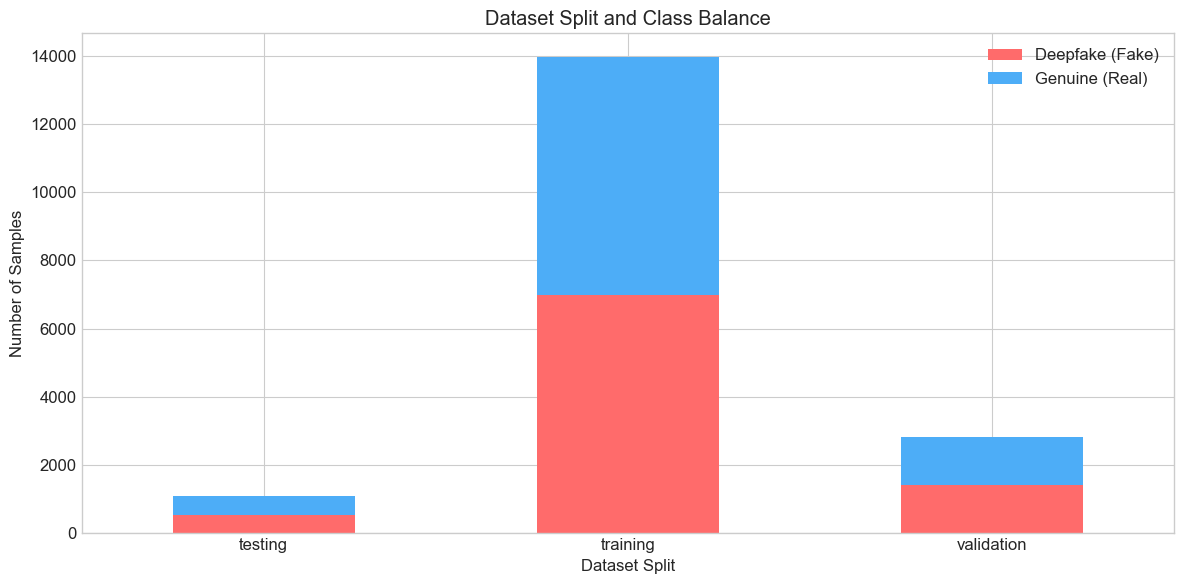

In [3]:
split_counts = df.groupby(['split', 'label']).size().unstack(fill_value=0)
print("Sample counts per split and label:")
print(split_counts)

# Plot split and label distribution
split_counts.plot(kind='bar', stacked=True, color=['#ff6b6b', '#4dadf7'])
plt.title('Dataset Split and Class Balance')
plt.xlabel('Dataset Split')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.legend(['Deepfake (Fake)', 'Genuine (Real)'])
plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=300)
plt.show()

## 3. Analyze Audio Durations, Sample Rates, and Channels

In [4]:
print("Duration Statistics (seconds):")
print(df['duration'].describe())

print("\nUnique Sample Rates:")
print(df['samplerate'].value_counts())

print("\nUnique Channel Configurations:")
print(df['channels'].value_counts())

Duration Statistics (seconds):
count    17870.0
mean         2.0
std          0.0
min          2.0
25%          2.0
50%          2.0
75%          2.0
max          2.0
Name: duration, dtype: float64

Unique Sample Rates:
samplerate
16000    17870
Name: count, dtype: int64

Unique Channel Configurations:
channels
1    17870
Name: count, dtype: int64


## 4. Visualize Waveforms and Mel Spectrograms

Let's select one real sample and one fake sample from the training set, load their waveforms, and plot their waveforms and mel-spectrograms.

In [5]:
real_sample_path = '../' + df[df['label'] == 'real']['filepath'].iloc[0]
fake_sample_path = '../' + df[df['label'] == 'fake']['filepath'].iloc[0]

y_real, sr_real = librosa.load(real_sample_path, sr=None)
y_fake, sr_fake = librosa.load(fake_sample_path, sr=None)

print(f"Real sample path: {real_sample_path} | Sample Rate: {sr_real} Hz | Shape: {y_real.shape}")
print(f"Fake sample path: {fake_sample_path} | Sample Rate: {sr_fake} Hz | Shape: {y_fake.shape}")

Real sample path: ../data\for-2seconds\training\real\file1000.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav | Sample Rate: 16000 Hz | Shape: (32000,)
Fake sample path: ../data\for-2seconds\training\fake\file10005.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav | Sample Rate: 16000 Hz | Shape: (32000,)


### Plot Waveforms

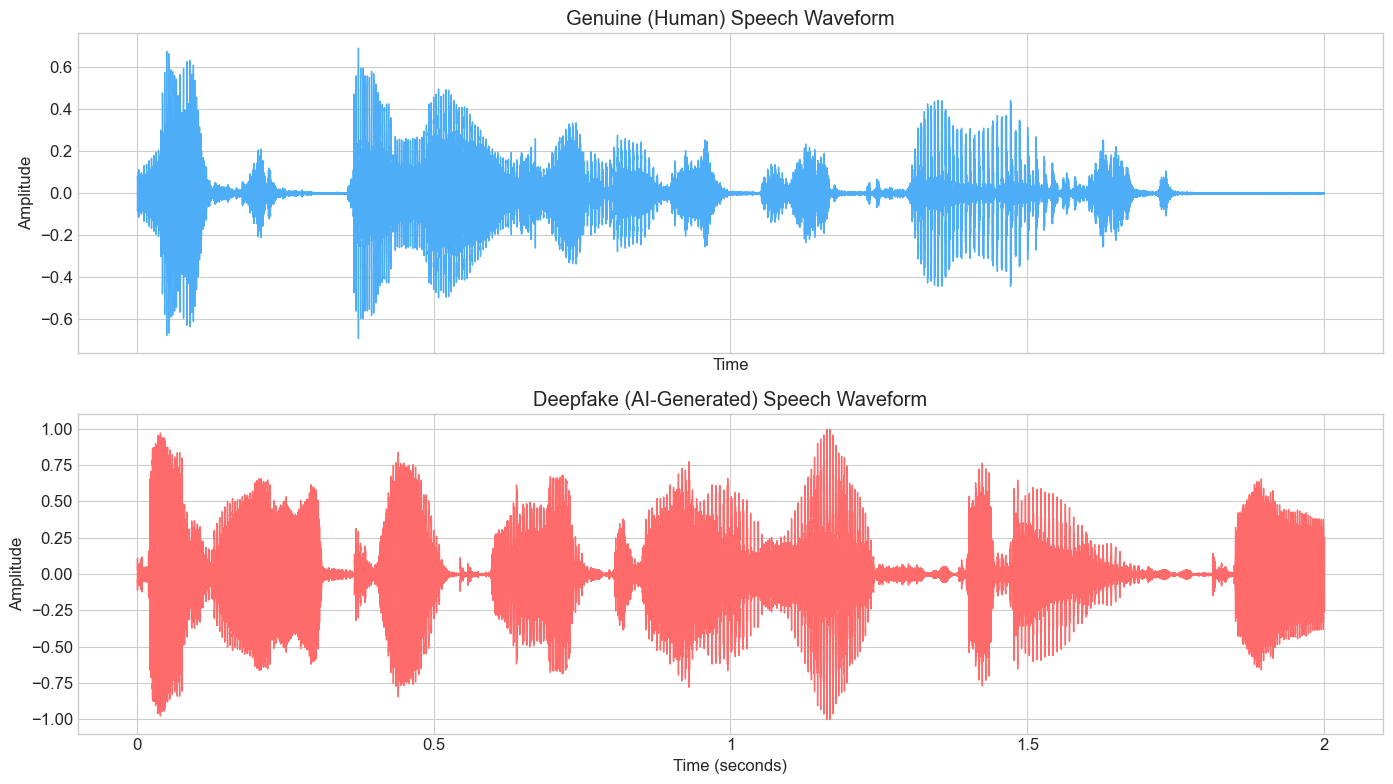

In [6]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 8))

librosa.display.waveshow(y_real, sr=sr_real, ax=axes[0], color='#4dadf7')
axes[0].set_title('Genuine (Human) Speech Waveform')
axes[0].set_ylabel('Amplitude')

librosa.display.waveshow(y_fake, sr=sr_fake, ax=axes[1], color='#ff6b6b')
axes[1].set_title('Deepfake (AI-Generated) Speech Waveform')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.savefig('../reports/waveforms_comparison.png', dpi=300)
plt.show()

### Plot Mel Spectrograms

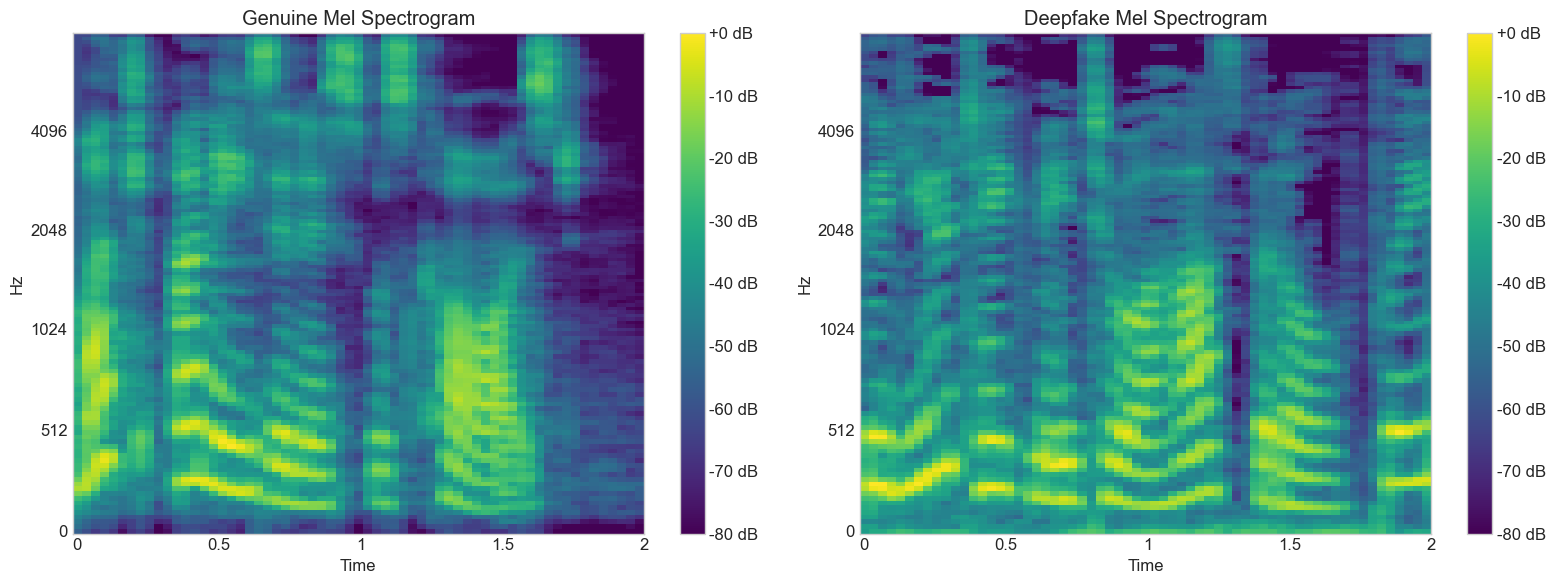

In [7]:
S_real = librosa.feature.melspectrogram(y=y_real, sr=sr_real, n_mels=128, fmax=8000)
S_real_db = librosa.power_to_db(S_real, ref=np.max)

S_fake = librosa.feature.melspectrogram(y=y_fake, sr=sr_fake, n_mels=128, fmax=8000)
S_fake_db = librosa.power_to_db(S_fake, ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

img1 = librosa.display.specshow(S_real_db, x_axis='time', y_axis='mel', sr=sr_real, fmax=8000, ax=axes[0], cmap='viridis')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')
axes[0].set_title('Genuine Mel Spectrogram')

img2 = librosa.display.specshow(S_fake_db, x_axis='time', y_axis='mel', sr=sr_fake, fmax=8000, ax=axes[1], cmap='viridis')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')
axes[1].set_title('Deepfake Mel Spectrogram')

plt.tight_layout()
plt.savefig('../reports/spectrograms_comparison.png', dpi=300)
plt.show()